In [1]:
from dotenv import load_dotenv
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from IPython.display import Image, display
import gradio as gr
from pydantic import BaseModel
import random


In [2]:
load_dotenv()

True

In [3]:
nouns = ["cat", "dog", "bird", "fish", "book", "tree", "computer", "phone", "car", "house"]
verbs = ["jumps", "runs", "flies", "swims", "reads", "writes", "drives", "eats", "sleeps", "thinks"]
adjectives = ["happy", "sad", "fast", "slow", "big", "small", "red", "blue", "green", "yellow"]

def generate_sentence(noun, verb, adjective):
    return f"{noun} {verb} {adjective}"


In [4]:
class State(BaseModel):

    messages : Annotated[list, add_messages]
    

In [5]:
mygraph = StateGraph(State)



In [6]:



def myNode1(oldstate: State) -> State:
    reply = f"{random.choice(nouns)} {random.choice(verbs)} {random.choice(adjectives)}"
    messages = [{"role": "assistant", "content": reply}]
    return State(messages=messages)

    

In [7]:
mygraph.add_node("myNode1", myNode1)
mygraph.add_edge(START, "myNode1")
mygraph.add_edge("myNode1", END)

graph = mygraph.compile()




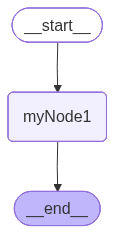

In [9]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
def chat(user_input: str, history):
    message = {"role":"user", "content":user_input}
    messages = [message]
    state = State(messages=messages)
    result = graph.invoke(state)
    print(result)
    return result["messages"][-1].content
    

In [ ]:
gr.ChatInterface(chat, title="LangGraph Demo", description="Ask anything you want", type = "messages").launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='hi there', additional_kwargs={}, response_metadata={}, id='6fc3328e-64c6-409c-8d89-57a7d9eb6039'), AIMessage(content='computer swims yellow', additional_kwargs={}, response_metadata={}, id='a59c8d14-5118-42c5-9b75-b6cfc5653f78')]}
{'messages': [HumanMessage(content='hello', additional_kwargs={}, response_metadata={}, id='f9d1bbfd-3c5f-4402-a724-2d916df7f92c'), AIMessage(content='car swims red', additional_kwargs={}, response_metadata={}, id='a616b6e9-8107-400e-9dc8-2ae66d403181')]}
{'messages': [HumanMessage(content='its not right', additional_kwargs={}, response_metadata={}, id='b9908ca1-ca9c-44bb-a09a-ef1ce7f55dde'), AIMessage(content='book runs big', additional_kwargs={}, response_metadata={}, id='73f006c8-66e8-415d-8ce4-004dbf72fc84')]}
{'messages': [HumanMessage(content='you are so wrong', additional_kwargs={}, response_metadata={}, id='eb128ea2-804e-4134-a71c-8fc520ef0c12'), AIMessage(content='phone flies blue', additional_kwargs={}, response_m